In [18]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [19]:
# Read the tags.tsv file into a DataFrame
data_dir = "../../datasets"
hmc_table_path = os.path.join(data_dir, "tags.tsv")
tags_df = pd.read_csv(hmc_table_path, sep='\t')

# Display the first few rows and info to understand the structure
print(tags_df.head())
print(tags_df.info())

# get number of unique project, srr, srs
num_unique_projects = tags_df['project'].nunique()
num_unique_srr = tags_df['srr'].nunique()
num_unique_srs = tags_df['srs'].nunique()

print(f"Number of unique projects: {num_unique_projects}")
print(f"Number of unique srr: {num_unique_srr}")
print(f"Number of unique srs: {num_unique_srs}")

      project        srr        srs                     tag           value
0  PRJDB10485  DRR243823  DRS176859       ART_drugs_current         control
1  PRJDB10485  DRR243823  DRS176859  ART_status_at_baseline         control
2  PRJDB10485  DRR243823  DRS176859               Education  primary school
3  PRJDB10485  DRR243823  DRS176859       HIV_risk_exposure    heterosexual
4  PRJDB10485  DRR243823  DRS176859          Marital_status         married
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489745 entries, 0 to 3489744
Data columns (total 5 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   project  object
 1   srr      object
 2   srs      object
 3   tag      object
 4   value    object
dtypes: object(5)
memory usage: 133.1+ MB
None
Number of unique projects: 482
Number of unique srr: 168464
Number of unique srs: 168464


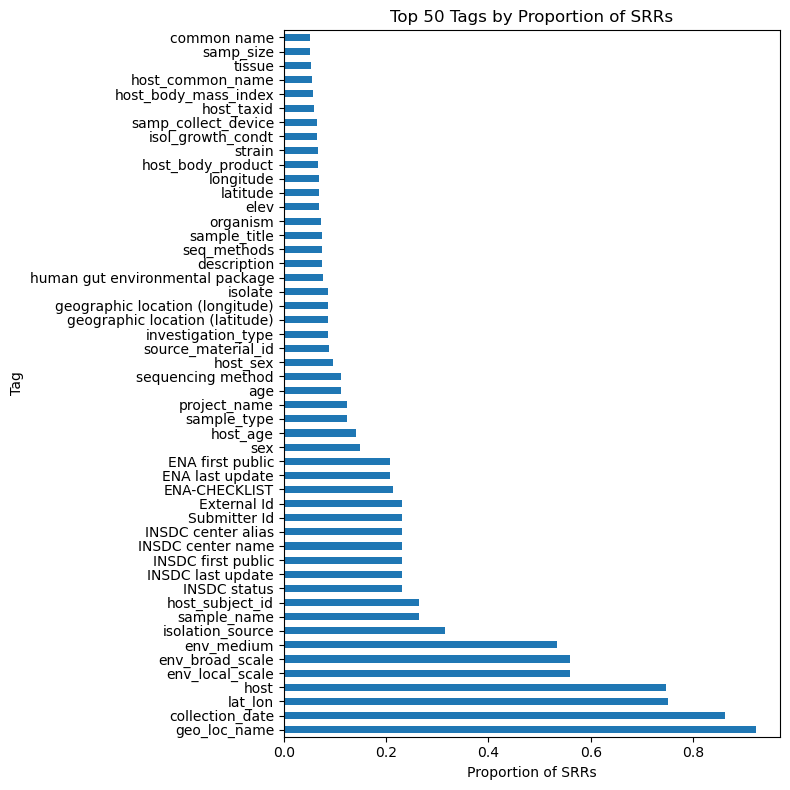

In [35]:
# Count frequency of each tag
tag_counts = tags_df['tag'].value_counts().head(50)
# divide by total unique srr
total_srr = tags_df['srr'].nunique()

tag_counts = tag_counts / total_srr
# tag_counts = tag_counts.reset_index()
tag_counts.columns = ['tag', 'proportion']

# plot
tag_counts.sort_values(ascending=False).plot(kind='barh', figsize=(8, 8))
plt.xlabel('Proportion of SRRs')
plt.ylabel('Tag')
plt.title('Top 50 Tags by Proportion of SRRs')
plt.tight_layout()
plt.show()

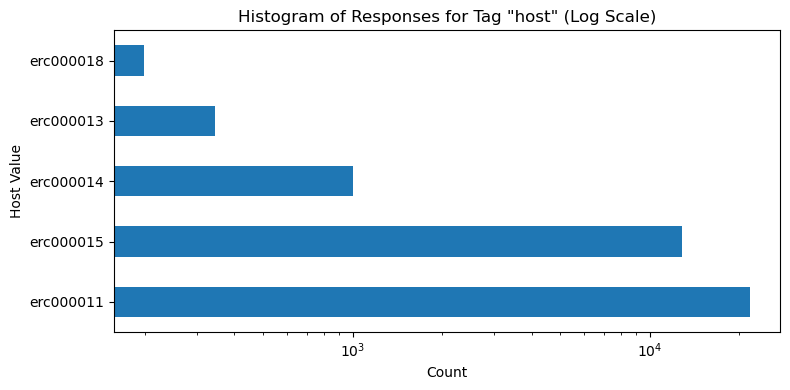

In [51]:
# Filter for rows where tag is 'x'
x = 'ENA-CHECKLIST'
host_values = tags_df[tags_df['tag'] == x]['value']

# Plot histogram of responses for 'x' with x-axis on log scale
plt.figure(figsize=(8, max(4, len(host_values.value_counts()) // 10)))
host_values.value_counts().plot(kind='barh')
plt.xlabel('Count')
plt.xscale('log')
plt.ylabel('Host Value')
plt.title('Histogram of Responses for Tag "host" (Log Scale)')
plt.tight_layout()
plt.show()

Get unique projects, and count how many srr are in each

Min SRRs per project: 50
Max SRRs per project: 4850
Median SRRs per project: 164.0
Mean SRRs per project: 349.5103734439834
Number of projects: 482


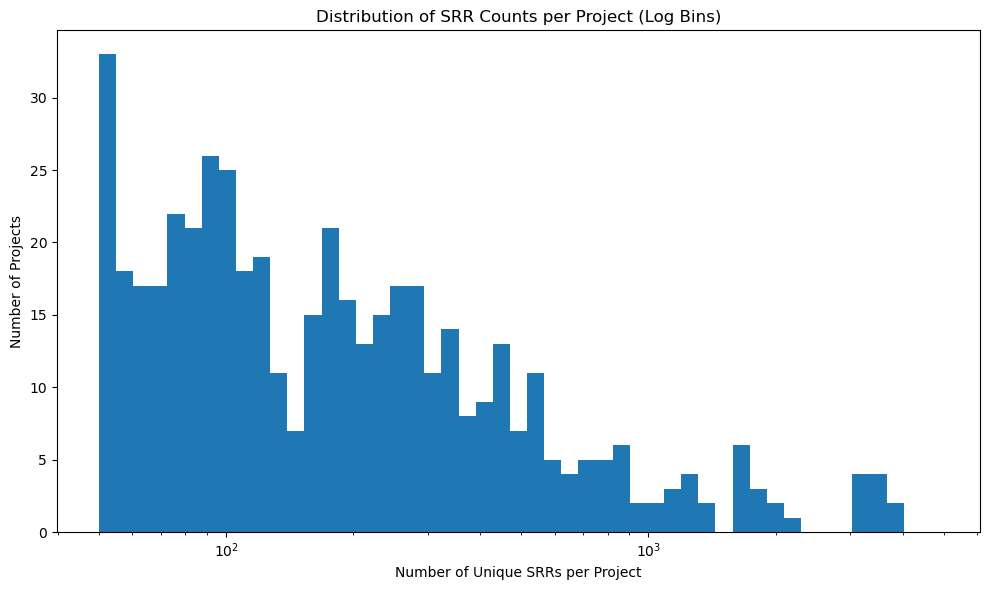

In [56]:
# Get unique projects and count how many SRRs are in each
project_srr_counts = tags_df.groupby('project')['srr'].nunique().sort_values(ascending=False)
print(f"Min SRRs per project: {project_srr_counts.min()}")
print(f"Max SRRs per project: {project_srr_counts.max()}")
print(f"Median SRRs per project: {project_srr_counts.median()}")
print(f"Mean SRRs per project: {project_srr_counts.mean()}")
print(f"Number of projects: {project_srr_counts.count()}")

# Plot histogram with log-scaled bins
plt.figure(figsize=(10, 6))
bins = np.logspace(np.log10(project_srr_counts.min()), np.log10(project_srr_counts.max()), 50)
project_srr_counts.plot(kind='hist', bins=bins)
plt.xlabel('Number of Unique SRRs per Project')
plt.ylabel('Number of Projects')
plt.xscale('log')
plt.title('Distribution of SRR Counts per Project (Log Bins)')
plt.tight_layout()
plt.show()

In [57]:
# Find SRRs that are associated with more than one unique SRS
srr_srs_counts = tags_df.groupby('srr')['srs'].nunique()
duplicate_srrs = srr_srs_counts[srr_srs_counts > 1]

print(f"Number of SRRs with more than one unique SRS: {len(duplicate_srrs)}")
if not duplicate_srrs.empty:
    print("Example SRRs with multiple SRS:")
    print(duplicate_srrs.head())
else:
    print("No SRRs are associated with more than one SRS.")

Number of SRRs with more than one unique SRS: 0
No SRRs are associated with more than one SRS.
